# **Introduction**

![](http://)**Hey guys, thanks for stopping by my notebook. I will be going over step by step on how to finish the Titanic competition with many different techniques. If you found this helpful, please drop an upvote : )**


1. IMPORTS
2. EDA
3. FEATURE ENGINEERING
4. MODELING (KNN, DECISION TREE, RANDOMFOREST, ETC)
5. HYPER PARAMATER TUNING
6. XG BOOST

If you hope you place high on the leaderboard, I suggest you check out my titanic model with neural networks! (Linked below)
https://www.kaggle.com/sshikamaru/titanic-keras-nn

![](https://kwmp.ca/wp-content/uploads/2018/04/titanic-the-musical-768x403.jpg)

In [1]:
#basic imports
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set()

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
print(os.walk('/kaggle/input'))

/kaggle/input/titanic/gender_submission.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/train.csv
<generator object walk at 0x7f4948630850>


In [2]:
#Import Train and Test data
train_data = pd.read_csv("/kaggle/input/titanic/train.csv")
test_data = pd.read_csv("/kaggle/input/titanic/test.csv")

In [3]:
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
test_data.head()


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [5]:
#Coorlation of people who survived given that they are a female
women = train_data.loc[train_data.Sex == 'female']["Survived"]
rate_women = sum(women)/len(women)

print("% of women who survived:", rate_women)

% of women who survived: 0.7420382165605095


# **Feature Enineering**

In [6]:
def bar_chart(feature):
    survived = train_data[train_data['Survived']==1][feature].value_counts()
    dead = train_data[train_data['Survived']==0][feature].value_counts()
    df = pd.DataFrame([survived,dead])
    df.index = ['Survived','Dead']
    df.plot(kind='bar',stacked=True, figsize=(10,5))

# **Title**

In [7]:

train_test_data = [train_data, test_data] # combining train and test dataset

for dataset in train_test_data:
    dataset['Title'] = dataset['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


title_mapping = {"Mr": 0, "Miss": 1, "Mrs": 2, 
                 "Master": 3, "Dr": 3, "Rev": 3, "Col": 3, "Major": 3, "Mlle": 3,"Countess": 3,
                 "Ms": 3, "Lady": 3, "Jonkheer": 3, "Don": 3, "Dona" : 3, "Mme": 3,"Capt": 3,"Sir": 3 }
for dataset in train_test_data:
    dataset['Title'] = dataset['Title'].map(title_mapping)
print(train_data['Title'])


0      0
1      2
2      1
3      2
4      0
      ..
886    3
887    1
888    1
889    0
890    0
Name: Title, Length: 891, dtype: int64


In [8]:
train_data.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0


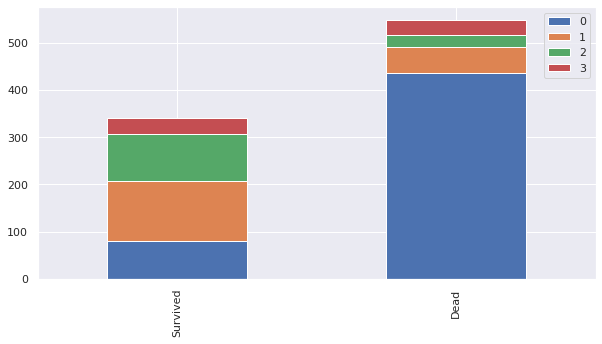

In [9]:
bar_chart('Title')

# **Gender**

In [10]:
sex_mapping = {"male": 0, "female":1}
for dataset in train_test_data:
    dataset['Sex'] = dataset['Sex'].map(sex_mapping)
print(train_data['Sex'])

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    1
889    0
890    0
Name: Sex, Length: 891, dtype: int64


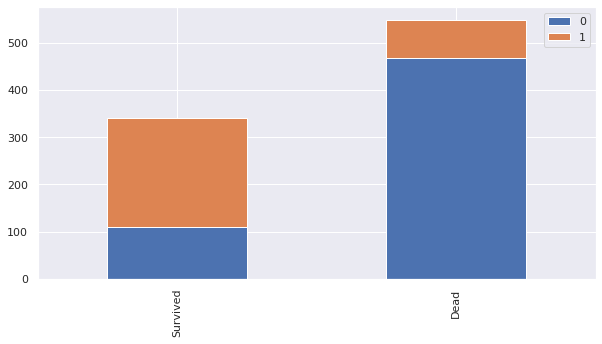

In [11]:
bar_chart('Sex')

# **Age**

In [12]:
train_data.head(10)
train_data["Age"].fillna(train_data.groupby("Title")["Age"].transform("median"), inplace=True)
test_data["Age"].fillna(test_data.groupby("Title")["Age"].transform("median"), inplace=True)


In [13]:
train_data.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,NaN,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,C85,C,2
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,C123,S,2
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,NaN,S,0
5,6,0,3,"Moran, Mr. James",0,30.0,0,0,330877,8.4583,NaN,Q,0
6,7,0,1,"McCarthy, Mr. Timothy J",0,54.0,0,0,17463,51.8625,E46,S,0
7,8,0,3,"Palsson, Master. Gosta Leonard",0,2.0,3,1,349909,21.0750,NaN,S,3
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",1,27.0,0,2,347742,11.1333,NaN,S,2
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",1,14.0,1,0,237736,30.0708,NaN,C,2


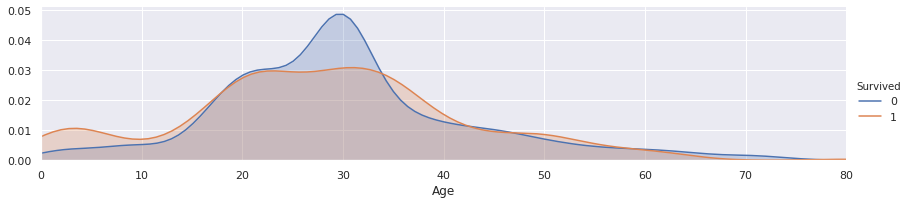

In [14]:

facet = sns.FacetGrid(train_data, hue="Survived",aspect=4)
facet.map(sns.kdeplot,'Age',shade= True)
facet.set(xlim=(0, train_data['Age'].max()))
facet.add_legend()
 
plt.show()

Binning/Converting Numerical Age to Categorical Variable

feature vector map:
child: 0
young: 1
adult: 2
mid-age: 3
senior: 4

In [15]:
for dataset in train_test_data:
    dataset.loc[ dataset['Age'] <= 16, 'Age'] = 0,
    dataset.loc[(dataset['Age'] > 16) & (dataset['Age'] <= 26), 'Age'] = 1,
    dataset.loc[(dataset['Age'] > 26) & (dataset['Age'] <= 36), 'Age'] = 2,
    dataset.loc[(dataset['Age'] > 36) & (dataset['Age'] <= 62), 'Age'] = 3,
    dataset.loc[ dataset['Age'] > 62, 'Age'] = 4

In [16]:
train_data.head(100)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",0,1.0,1,0,A/5 21171,7.2500,NaN,S,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,3.0,1,0,PC 17599,71.2833,C85,C,2
2,3,1,3,"Heikkinen, Miss. Laina",1,1.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,2.0,1,0,113803,53.1000,C123,S,2
4,5,0,3,"Allen, Mr. William Henry",0,2.0,0,0,373450,8.0500,NaN,S,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,0,3,"Shorney, Mr. Charles Joseph",0,2.0,0,0,374910,8.0500,NaN,S,0
96,97,0,1,"Goldschmidt, Mr. George B",0,4.0,0,0,PC 17754,34.6542,A5,C,0
97,98,1,1,"Greenfield, Mr. William Bertram",0,1.0,0,1,PC 17759,63.3583,D10 D12,C,0
98,99,1,2,"Doling, Mrs. John T (Ada Julia Bone)",1,2.0,0,1,231919,23.0000,NaN,S,2


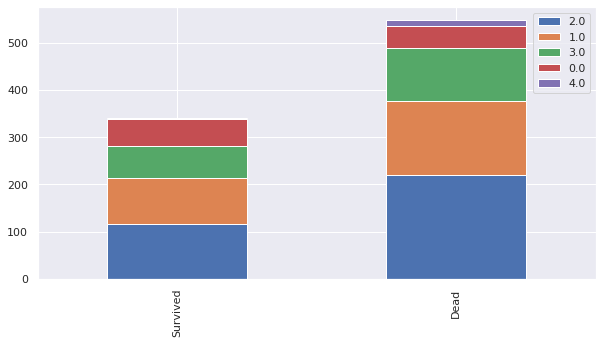

In [17]:
bar_chart('Age')

# **Embarked**

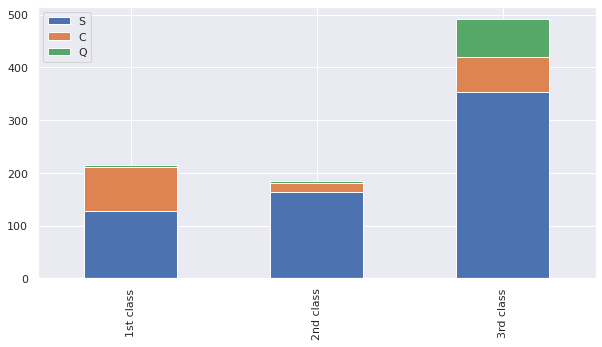

In [18]:
Pclass1 = train_data[train_data['Pclass'] == 1]['Embarked'].value_counts()
Pclass2 = train_data[train_data['Pclass'] == 2]['Embarked'].value_counts()
Pclass3 = train_data[train_data['Pclass'] == 3]['Embarked'].value_counts()

df = pd.DataFrame([Pclass1, Pclass2, Pclass3])
df.index = ['1st class','2nd class', '3rd class']
df.plot(kind='bar',stacked=True, figsize=(10,5))

In [19]:
for data in train_test_data:
    data['Embarked'] = data['Embarked'].fillna("S")
    
embarked_mapping = {"S": 0, "C": 1, "Q": 2}
for dataset in train_test_data:
    dataset['Embarked'] = dataset['Embarked'].map(embarked_mapping)


In [20]:
train_data.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",0,1.0,1,0,A/5 21171,7.2500,NaN,0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,3.0,1,0,PC 17599,71.2833,C85,1,2
2,3,1,3,"Heikkinen, Miss. Laina",1,1.0,0,0,STON/O2. 3101282,7.9250,NaN,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,2.0,1,0,113803,53.1000,C123,0,2
4,5,0,3,"Allen, Mr. William Henry",0,2.0,0,0,373450,8.0500,NaN,0,0
5,6,0,3,"Moran, Mr. James",0,2.0,0,0,330877,8.4583,NaN,2,0
6,7,0,1,"McCarthy, Mr. Timothy J",0,3.0,0,0,17463,51.8625,E46,0,0
7,8,0,3,"Palsson, Master. Gosta Leonard",0,0.0,3,1,349909,21.0750,NaN,0,3
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",1,2.0,0,2,347742,11.1333,NaN,0,2
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",1,0.0,1,0,237736,30.0708,NaN,1,2


# **Fare**

In [21]:
train_data["Fare"].fillna(train_data.groupby("Pclass")["Fare"].transform("median"), inplace=True)
test_data["Fare"].fillna(test_data.groupby("Pclass")["Fare"].transform("median"), inplace=True)
train_data.head(20)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",0,1.0,1,0,A/5 21171,7.2500,NaN,0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,3.0,1,0,PC 17599,71.2833,C85,1,2
2,3,1,3,"Heikkinen, Miss. Laina",1,1.0,0,0,STON/O2. 3101282,7.9250,NaN,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,2.0,1,0,113803,53.1000,C123,0,2
4,5,0,3,"Allen, Mr. William Henry",0,2.0,0,0,373450,8.0500,NaN,0,0
5,6,0,3,"Moran, Mr. James",0,2.0,0,0,330877,8.4583,NaN,2,0
6,7,0,1,"McCarthy, Mr. Timothy J",0,3.0,0,0,17463,51.8625,E46,0,0
7,8,0,3,"Palsson, Master. Gosta Leonard",0,0.0,3,1,349909,21.0750,NaN,0,3
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",1,2.0,0,2,347742,11.1333,NaN,0,2
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",1,0.0,1,0,237736,30.0708,NaN,1,2


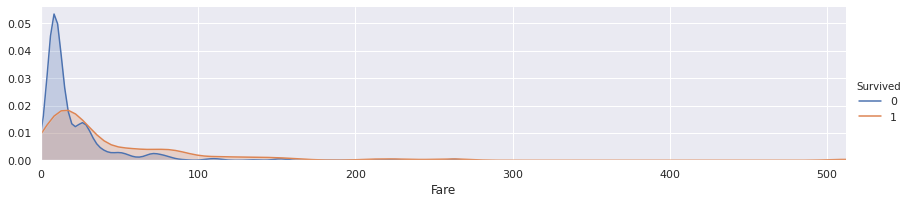

In [22]:
facet = sns.FacetGrid(train_data, hue="Survived",aspect=4)
facet.map(sns.kdeplot,'Fare',shade= True)
facet.set(xlim=(0, train_data['Fare'].max()))
facet.add_legend()
 
plt.show()

(0.0, 30.0)

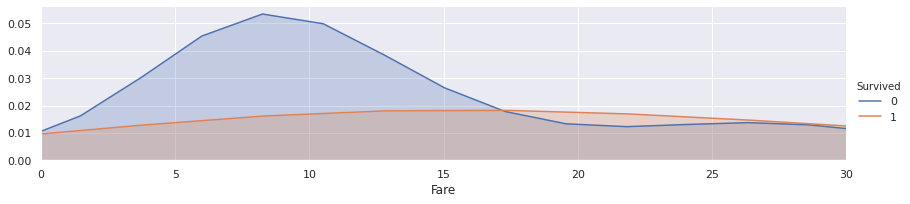

In [23]:

facet = sns.FacetGrid(train_data, hue="Survived",aspect=4)
facet.map(sns.kdeplot,'Fare',shade= True)
facet.set(xlim=(0, train_data['Fare'].max()))
facet.add_legend()
plt.xlim(0, 30)

In [24]:
for dataset in train_test_data:
    dataset.loc[ dataset['Fare'] <= 17, 'Fare'] = 0,
    dataset.loc[(dataset['Fare'] > 17) & (dataset['Fare'] <= 30), 'Fare'] = 1,
    dataset.loc[(dataset['Fare'] > 30) & (dataset['Fare'] <= 100), 'Fare'] = 2,
    dataset.loc[ dataset['Fare'] > 100, 'Fare'] = 3

# **Cabin**

In [25]:
train_data.Cabin.value_counts()


B96 B98        4
C23 C25 C27    4
G6             4
D              3
C22 C26        3
              ..
C30            1
D7             1
B78            1
B42            1
B101           1
Name: Cabin, Length: 147, dtype: int64

In [26]:
test_text = 'abc'
print(test_text[:1])
for data in train_test_data:
    data["Cabin"] = data["Cabin"].str[:1]
train_data.head()

a


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",0,1.0,1,0,A/5 21171,0.0,NaN,0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,3.0,1,0,PC 17599,2.0,C,1,2
2,3,1,3,"Heikkinen, Miss. Laina",1,1.0,0,0,STON/O2. 3101282,0.0,NaN,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,2.0,1,0,113803,2.0,C,0,2
4,5,0,3,"Allen, Mr. William Henry",0,2.0,0,0,373450,0.0,NaN,0,0


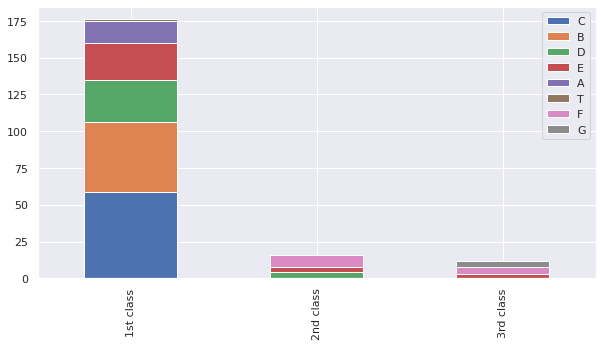

In [27]:
Pclass1 = train_data[train_data['Pclass'] == 1]['Cabin'].value_counts()
Pclass2 = train_data[train_data['Pclass'] == 2]['Cabin'].value_counts()
Pclass3 = train_data[train_data['Pclass'] == 3]['Cabin'].value_counts()
df = pd.DataFrame([Pclass1,Pclass2, Pclass3])
df.index = ['1st class','2nd class', '3rd class']
df.plot(kind='bar',stacked=True, figsize=(10,5))


In [28]:
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",0,1.0,1,0,A/5 21171,0.0,NaN,0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,3.0,1,0,PC 17599,2.0,C,1,2
2,3,1,3,"Heikkinen, Miss. Laina",1,1.0,0,0,STON/O2. 3101282,0.0,NaN,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,2.0,1,0,113803,2.0,C,0,2
4,5,0,3,"Allen, Mr. William Henry",0,2.0,0,0,373450,0.0,NaN,0,0


In [29]:
cabin_mapping = {"A": 0, "B": 0.4, "C": 0.8, "D": 1.2, "E": 1.6, "F": 2, "G": 2.4, "T": 2.8}
for dataset in train_test_data:
    dataset['Cabin'] = dataset['Cabin'].map(cabin_mapping)
    

In [30]:
#fill in missing values
train_data["Cabin"].fillna(train_data.groupby("Pclass")["Cabin"].transform("median"), inplace=True)
test_data["Cabin"].fillna(test_data.groupby("Pclass")["Cabin"].transform("median"), inplace=True)

# **Family Size**

In [31]:
train_data["FamilySize"] = train_data['SibSp'] + train_data['Parch'] + 1
test_data["FamilySize"] = test_data['SibSp'] + test_data['Parch'] + 1

(0.0, 11.0)

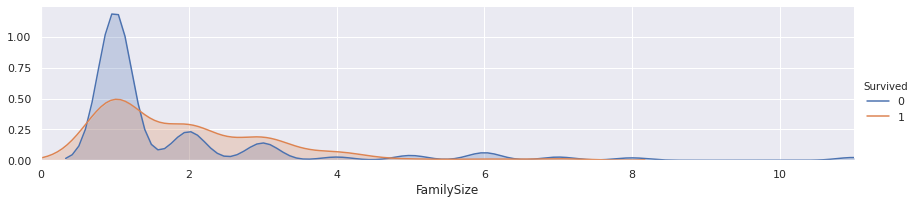

In [32]:

facet = sns.FacetGrid(train_data, hue="Survived",aspect=4)
facet.map(sns.kdeplot,'FamilySize',shade= True)
facet.set(xlim=(0, train_data['FamilySize'].max()))
facet.add_legend()
plt.xlim(0)

In [33]:
#adding it to the dataset
family_mapping = {1: 0, 2: 0.4, 3: 0.8, 4: 1.2, 5: 1.6, 6: 2, 7: 2.4, 8: 2.8, 9: 3.2, 10: 3.6, 11: 4}
for dataset in train_test_data:
    dataset['FamilySize'] = dataset['FamilySize'].map(family_mapping)

In [34]:
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamilySize
0,1,0,3,"Braund, Mr. Owen Harris",0,1.0,1,0,A/5 21171,0.0,2.0,0,0,0.4
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,3.0,1,0,PC 17599,2.0,0.8,1,2,0.4
2,3,1,3,"Heikkinen, Miss. Laina",1,1.0,0,0,STON/O2. 3101282,0.0,2.0,0,1,0.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,2.0,1,0,113803,2.0,0.8,0,2,0.4
4,5,0,3,"Allen, Mr. William Henry",0,2.0,0,0,373450,0.0,2.0,0,0,0.0


# **Dropping**

In [35]:
features_drop = ['Ticket', 'SibSp', 'Parch']
train_data = train_data.drop(features_drop, axis =1)
test_data = test_data.drop(features_drop, axis=1)
train_data = train_data.drop(['PassengerId'], axis=1)

# **Class**

In [36]:
train_data.head()

,Survived,Pclass,Name,Sex,Age,Fare,Cabin,Embarked,Title,FamilySize
0,0,3,"Braund, Mr. Owen Harris",0,1.0,0.0,2.0,0,0,0.4
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,3.0,2.0,0.8,1,2,0.4
2,1,3,"Heikkinen, Miss. Laina",1,1.0,0.0,2.0,0,1,0.0
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,2.0,2.0,0.8,0,2,0.4
4,0,3,"Allen, Mr. William Henry",0,2.0,0.0,2.0,0,0,0.0


In [37]:
test_data.head()

,PassengerId,Pclass,Name,Sex,Age,Fare,Cabin,Embarked,Title,FamilySize
0,892,3,"Kelly, Mr. James",0,2.0,0.0,2.0,2,0,0.0
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",1,3.0,0.0,2.0,0,2,0.4
2,894,2,"Myles, Mr. Thomas Francis",0,3.0,0.0,2.0,2,0,0.0
3,895,3,"Wirz, Mr. Albert",0,2.0,0.0,2.0,0,0,0.0
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",1,1.0,0.0,2.0,0,2,0.8


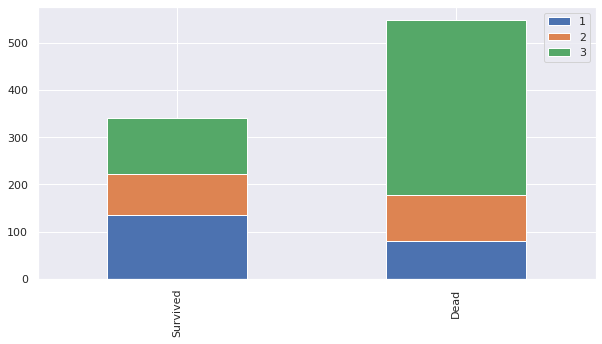

In [38]:
bar_chart('Pclass')


In [39]:
train_data.shape
test_data.shape

(418, 10)

# **Modeling**

In [40]:
#imports
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn import model_selection
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import accuracy_score

import numpy as np


In [41]:
train_data.info

<bound method DataFrame.info of      Survived  Pclass                                               Name  Sex  \
0           0       3                            Braund, Mr. Owen Harris    0   
1           1       1  Cumings, Mrs. John Bradley (Florence Briggs Th...    1   
2           1       3                             Heikkinen, Miss. Laina    1   
3           1       1       Futrelle, Mrs. Jacques Heath (Lily May Peel)    1   
4           0       3                           Allen, Mr. William Henry    0   
..        ...     ...                                                ...  ...   
886         0       2                              Montvila, Rev. Juozas    0   
887         1       1                       Graham, Miss. Margaret Edith    1   
888         0       3           Johnston, Miss. Catherine Helen "Carrie"    1   
889         1       1                              Behr, Mr. Karl Howell    0   
890         0       3                                Dooley, Mr. Patrick    0

# **Split Data**

Let's use train_test_split to split our data for validation!

In [42]:
train_data.head()

,Survived,Pclass,Name,Sex,Age,Fare,Cabin,Embarked,Title,FamilySize
0,0,3,"Braund, Mr. Owen Harris",0,1.0,0.0,2.0,0,0,0.4
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,3.0,2.0,0.8,1,2,0.4
2,1,3,"Heikkinen, Miss. Laina",1,1.0,0.0,2.0,0,1,0.0
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,2.0,2.0,0.8,0,2,0.4
4,0,3,"Allen, Mr. William Henry",0,2.0,0.0,2.0,0,0,0.0


In [43]:
target = train_data['Survived']
id = test_data['PassengerId']

train_data.drop('Survived', axis=1, inplace = True)
train_data.drop('Name', axis=1, inplace = True)

test_data.drop('Name', axis=1, inplace = True)
test_data.head()
train_data.head()

train = train_data
test = test_data

In [44]:
#X_train, X_test, y_train, y_train = train_test_split(train_data, survived, random_state=0, test_size=0.2, shuffle=False)

#  **Cross Validation K fold**

In [45]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
k_fold = KFold(n_splits = 10, shuffle = True, random_state = 0)


train_data.shape, target.shape
train_data.head()


,Pclass,Sex,Age,Fare,Cabin,Embarked,Title,FamilySize
0,3,0,1.0,0.0,2.0,0,0,0.4
1,1,1,3.0,2.0,0.8,1,2,0.4
2,3,1,1.0,0.0,2.0,0,1,0.0
3,1,1,2.0,2.0,0.8,0,2,0.4
4,3,0,2.0,0.0,2.0,0,0,0.0


In [46]:
test_data.head()

,PassengerId,Pclass,Sex,Age,Fare,Cabin,Embarked,Title,FamilySize
0,892,3,0,2.0,0.0,2.0,2,0,0.0
1,893,3,1,3.0,0.0,2.0,0,2,0.4
2,894,2,0,3.0,0.0,2.0,2,0,0.0
3,895,3,0,2.0,0.0,2.0,0,0,0.0
4,896,3,1,1.0,0.0,2.0,0,2,0.8


In [47]:
test.head()

,PassengerId,Pclass,Sex,Age,Fare,Cabin,Embarked,Title,FamilySize
0,892,3,0,2.0,0.0,2.0,2,0,0.0
1,893,3,1,3.0,0.0,2.0,0,2,0.4
2,894,2,0,3.0,0.0,2.0,2,0,0.0
3,895,3,0,2.0,0.0,2.0,0,0,0.0
4,896,3,1,1.0,0.0,2.0,0,2,0.8


In [48]:
#coltest = train.drop('Cabin', axis=1)
#coltest = coltest.drop('Embarked', axis=1)
#coltest = coltest.drop('Title', axis=1)
#coltest = coltest.drop('Age', axis=1)


clf = KNeighborsClassifier(n_neighbors = 50)
scoring = 'accuracy'
score = cross_val_score(clf, train, target, cv = k_fold, n_jobs = 1, scoring = scoring)
print(score)
print(np.mean(score))



[0.77777778 0.7752809  0.82022472 0.7752809  0.7752809  0.82022472
 0.82022472 0.78651685 0.79775281 0.82022472]
0.7968789013732834


# **KNN**

In [49]:
clf = LogisticRegression()
scoring = 'accuracy'
score = cross_val_score(clf, train, target, cv = k_fold, n_jobs = 1, scoring = scoring)
print(score)
print(np.mean(score))

[0.8        0.7752809  0.80898876 0.78651685 0.80898876 0.82022472
 0.80898876 0.84269663 0.82022472 0.85393258]
0.8125842696629213


In [50]:
from sklearn.linear_model import LogisticRegression
clf = KNeighborsClassifier(n_neighbors = 13)
scoring = 'accuracy'
score = cross_val_score(clf, train, target, cv = k_fold, n_jobs = 1, scoring = scoring)
print(score)
print(np.mean(score))

[0.82222222 0.76404494 0.80898876 0.83146067 0.87640449 0.82022472
 0.85393258 0.79775281 0.84269663 0.84269663]
0.8260424469413232


# **Random Forest**

In [51]:
clf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=1)
scoring = 'accuracy'
score = cross_val_score(clf, train, target, cv = k_fold, n_jobs = 1, scoring = scoring)
print(score)
print(np.mean(score))

[0.82222222 0.84269663 0.82022472 0.80898876 0.87640449 0.82022472
 0.82022472 0.79775281 0.7752809  0.83146067]
0.8215480649188514


# **Naive Beyes**

In [52]:
clf = GaussianNB()
scoring = 'accuracy'
score = cross_val_score(clf, train, target, cv = k_fold, n_jobs = 1, scoring = scoring)
print(score)
print(np.mean(score))

[0.85555556 0.73033708 0.75280899 0.75280899 0.70786517 0.80898876
 0.76404494 0.80898876 0.86516854 0.83146067]
0.7878027465667914


# **SVM**

In [53]:
train.head()

,Pclass,Sex,Age,Fare,Cabin,Embarked,Title,FamilySize
0,3,0,1.0,0.0,2.0,0,0,0.4
1,1,1,3.0,2.0,0.8,1,2,0.4
2,3,1,1.0,0.0,2.0,0,1,0.0
3,1,1,2.0,2.0,0.8,0,2,0.4
4,3,0,2.0,0.0,2.0,0,0,0.0


In [54]:
test.head()

,PassengerId,Pclass,Sex,Age,Fare,Cabin,Embarked,Title,FamilySize
0,892,3,0,2.0,0.0,2.0,2,0,0.0
1,893,3,1,3.0,0.0,2.0,0,2,0.4
2,894,2,0,3.0,0.0,2.0,2,0,0.0
3,895,3,0,2.0,0.0,2.0,0,0,0.0
4,896,3,1,1.0,0.0,2.0,0,2,0.8


In [55]:
clf = SVC()
scoring = 'accuracy'
score = cross_val_score(clf, train, target, cv = k_fold, n_jobs = 1, scoring = scoring)
print(score)
clf.fit(train, target)
print(np.mean(score))

y_pred = clf.predict(test)

pred=pd.DataFrame(y_pred)
print(pred)

[0.83333333 0.79775281 0.83146067 0.82022472 0.84269663 0.82022472
 0.84269663 0.85393258 0.84269663 0.86516854]
0.8350187265917602


ValueError: X.shape[1] = 9 should be equal to 8, the number of features at training time

# **XGBOOST**

In [56]:
'''xgb = xgb.XGBClassifier(random_state=0)
xgb.fit(train, target)
preds = xgb.predict(test)
print('XGBoost: ', accuracy_score(y_val, preds))

def create_model(trial):
    max_depth = trial.suggest_int("max_depth", 2, 30)
    n_estimators = trial.suggest_int("n_estimators", 1, 500)
    learning_rate = trial.suggest_uniform('learning_rate', 0.0000001, 1)
    gamma = trial.suggest_uniform('gamma', 0.0000001, 1)
    model = XGBClassifier(learning_rate=learning_rate, n_estimators=n_estimators, max_depth=max_depth, gamma=gamma, random_state=0)
    return model

def objective(trial):
    model = create_model(trial)
    model.fit(X, y)
    preds = model.predict(X_val)
    score = accuracy_score(y_val, preds)
    return score

study = optuna.create_study(direction="maximize", sampler=sampler)
study.optimize(objective, n_trials=50)

xgb_params = study.best_params
xgb_params['random_state'] = 0
'''

'xgb = xgb.XGBClassifier(random_state=0)\nxgb.fit(train, target)\npreds = xgb.predict(test)\nprint(\'XGBoost: \', accuracy_score(y_val, preds))\n\ndef create_model(trial):\n    max_depth = trial.suggest_int("max_depth", 2, 30)\n    n_estimators = trial.suggest_int("n_estimators", 1, 500)\n    learning_rate = trial.suggest_uniform(\'learning_rate\', 0.0000001, 1)\n    gamma = trial.suggest_uniform(\'gamma\', 0.0000001, 1)\n    model = XGBClassifier(learning_rate=learning_rate, n_estimators=n_estimators, max_depth=max_depth, gamma=gamma, random_state=0)\n    return model\n\ndef objective(trial):\n    model = create_model(trial)\n    model.fit(X, y)\n    preds = model.predict(X_val)\n    score = accuracy_score(y_val, preds)\n    return score\n\nstudy = optuna.create_study(direction="maximize", sampler=sampler)\nstudy.optimize(objective, n_trials=50)\n\nxgb_params = study.best_params\nxgb_params[\'random_state\'] = 0\n'

In [57]:
'''xgb = XGBClassifier(**xgb_params)
xgb.fit(X, y)
#preds = xgb.predict(X_val)
#print('Optimied XGBoost: ', accuracy_score(y_val, preds))'''


"xgb = XGBClassifier(**xgb_params)\nxgb.fit(X, y)\n#preds = xgb.predict(X_val)\n#print('Optimied XGBoost: ', accuracy_score(y_val, preds))"

In [58]:


pred=pd.DataFrame(y_pred)
sub = pd.concat([test_data['PassengerId'],pred], axis=1)
sub.columns=['PassengerId','Survived']
sub.to_csv('submission66.csv', index = False)
print(sub.to_csv)

NameError: name 'y_pred' is not defined

In [59]:

#submission = pd.read_csv('submission1.csv')
#submission.head()

# **Decision Tree**

In [60]:
clf = DecisionTreeClassifier()
scoring = 'accuracy'
score = cross_val_score(clf, train, target, cv = k_fold, n_jobs = 1, scoring = scoring)
print(score)
print(np.mean(score))

[0.76666667 0.82022472 0.7752809  0.7752809  0.88764045 0.75280899
 0.83146067 0.82022472 0.74157303 0.79775281]
0.7968913857677904



References

Minsuk Heo 허민석
This notebook is created by learning from the following notebooks:

Mukesh ChapagainTitanic Solution: A Beginner's Guide
How to score 0.8134 in Titanic Kaggle Challenge
Titanic: factors to survive
Titanic Survivors Dataset and Data Wrangling